In [109]:
import pandas as pd
import matplotlib as plt
import matplotlib.pyplot as pltp
import numpy as np
import random

In [110]:
def p_vec(E, p, theta, rho):
    vec=np.array([E, p, theta, rho])
    return vec

In [111]:
def E_m1(M,m1,m2):
    E = (M**2 + m1**2 - m2**2)/(2*M)
    return E

def p_m1(M, m1, m2):
    p = (np.sqrt((M**2 + m1**2 - m2**2)**2 - 4*(M**2)*(m1**2)))/(2*M)
    return p

In [112]:
def generate(M, m1, m2):
    theta = random.uniform(0, 2*np.pi)
    phi = random.uniform(0, np.pi)
    theta2 = (np.pi + theta)%(2*np.pi)
    phi2 = np.pi - phi


    E1 = E_m1(M, m1, m2)
    E2 = E_m1(M, m2, m1)
    p1 = p_m1(M, m1, m2)
    p2 = p_m1(M, m2, m1)
    return p_vec(E1, p1,theta, phi), p_vec(E2, p2 ,theta2, phi2)

def sample_exponential_truncated(m_min, m_max, scale):
    """Sample from an exponential distribution truncated to [m_min, m_max]."""
    while True:
        x = np.random.exponential(scale=scale)
        if m_min <= x <= m_max:
            return x
        
def gen_inv_mass(m1, p1):
    M_inv = 2*np.sqrt(m1**2 + p1**2)
    return M_inv

In [ ]:
def generate_Jpsi_pp():
    v1, v2 = generate(3.0969, 0.93827, 0.93827)
    return v1, v2
def generate_Jpsi_uu():
    v1, v2 = generate(3.0969, 0.10566, 0.10566)
    return v1, v2
def generate_Jpsi_ee():
    v1, v2 = generate(3.0969, 0.000511, 0.000511)
    return v1, v2
def generate_phi_kk():
    v1, v2 = generate(1.01946, 0.493677, 0.493677)
    return v1, v2
def generate_phi_uu():
    v1, v2 = generate(1.01946, 0.10566, 0.10566)
    return v1, v2
def generate_gammagamma_uu():
    mgg = sample_exponential_truncated(2*0.10566, 7, 1)
    v1, v2 = generate(mgg, 0.10566, 0.10566)
    return v1, v2
def generate_gammagamma_ee():
    mgg = sample_exponential_truncated(2*0.000511, 7, 1)
    v1, v2 = generate(mgg, 0.000511, 0.000511)
    return v1, v2
def generate_gammagamma_kk():
    mgg = sample_exponential_truncated(2*0.493677, 7, 1)
    v1, v2 = generate(mgg, 0.493677, 0.493677)
    return v1, v2

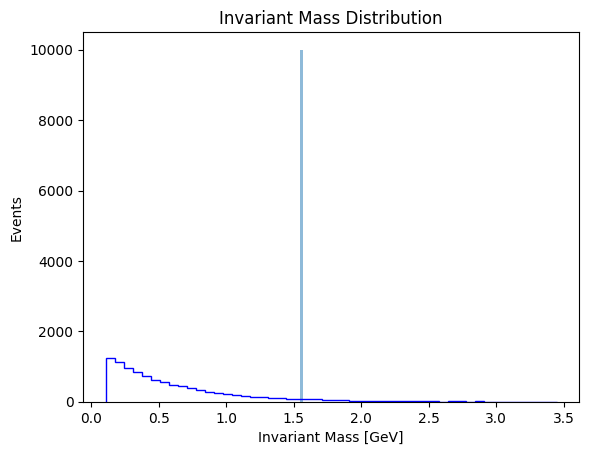

In [121]:
N = 10000
masses = []
masses1 = []
for _ in range(N):
    v1, v2= generate_gammagamma_uu()
    v1p, v2p= generate_Jpsi_uu()
    masses.append(v1[0])
    masses1.append(v1p[0])
# plot histogram
pltp.hist(masses, bins=50, histtype='step', color='blue')
pltp.hist(masses1, bins=50, alpha=0.5, label="Process B")
pltp.xlabel("Invariant Mass [GeV]")
pltp.ylabel("Events")
pltp.title("Invariant Mass Distribution")
pltp.show()

In [ ]:
plt.hist(masses, bins=50, histtype='step', color='blue')
plt.xlabel("Invariant Mass [GeV]")
plt.ylabel("Events")
plt.title("Invariant Mass Distribution")
plt.show()